# Valores faltantes

## Carga dataset

In [1]:
import pandas as pd

df = pd.read_csv('NovaMarket_datos_crudos 2.csv')
print(df.shape)
df.head()

(640000, 20)


,id_pedido,id_cliente,fecha_pedido,canal_compra,metodo_pago,ciudad_tienda,codigo_postal,categoria_producto,producto,precio_unitario,unidades_vendidas,monto_compra,edad_cliente,correo_cliente,nivel_satisfaccion,nivel_lealtad,comentario_cliente,peso_pedido_kg,fecha_actualizacion_stock,fuga_cliente
0,P505195,C45650,15/11/2025,Tienda,Efectivo,bogota,1100103,Moda,Chaqueta impermeable,28700.0,1,28700.0,32,cliente405195@novamarket.com.co,Bajo,Platino,El domiciliario fue muy amable,14.9,2026-04-17,0
1,P677836,C84260,2026-03-05,Web,Efectivo,MZL,1700101,Electrónica,Parlante bluetooth,195700.0,2,391400.0,73,cliente577836@yahoo.es,Medio,Bronce,El producto llegó dañado,12.9,2026-06-10,0
2,P387869,C164166,2025-03-13,Tienda,PayPal,Cúcuta,5400101,Juguetería,Rompecabezas 1000 piezas,597600.0,-3,-1792800.0,32,cliente287869@novamarket.com.co,Bajo,Oro,El domiciliario fue muy amable,14.3,2026-02-26,0
3,P481069,C98406,27/06/2025,App,transferencia,Cucuta,5400103,deportes,Colchoneta de yoga,322900.0,1,322900.0,45,cliente381069@gmail.com,Medio,Platino,Rápido y sin problemas,9.5,2026-05-14,0
4,P247920,C163018,01/05/2025,Web,Efectivo,Bucaramanga,6800112,Hogar,Juego de sábanas,222400.0,1,222400.0,60,cliente147920@novamarket.com.co,Alto,Plata,NaN,12.3,2026-07-13,0


## Ubica de nuevo tus columnas con vacíos

Identificamos nuevamente las columnas con valores faltantes y su cantidad exacta de registros faltantes.


In [2]:
df.isnull().sum()

id_pedido                         0
id_cliente                        0
fecha_pedido                      0
canal_compra                      0
metodo_pago                       0
ciudad_tienda                 29928
codigo_postal                     0
categoria_producto                0
producto                          0
precio_unitario               21640
unidades_vendidas                 0
monto_compra                  21640
edad_cliente                      0
correo_cliente               105312
nivel_satisfaccion            46469
nivel_lealtad                     0
comentario_cliente            90806
peso_pedido_kg                    0
fecha_actualizacion_stock         0
fuga_cliente                      0
dtype: int64

### Porcentaje de faltantes

Se calcula el porcentaje de valores faltantes de cada columna para documentarlo en la tabla de decisiones.


In [3]:
porcentaje_faltantes = (df.isnull().mean() * 100).round(2)
porcentaje_faltantes[porcentaje_faltantes > 0].sort_values(ascending=False)

correo_cliente        16.46
comentario_cliente    14.19
nivel_satisfaccion     7.26
ciudad_tienda          4.68
precio_unitario        3.38
monto_compra           3.38
dtype: float64

Las columnas que se diagnostican esta semana son `correo_cliente`, `nivel_satisfaccion`, `ciudad_tienda` y `precio_unitario`.


## Visualiza el mapa de nulos


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

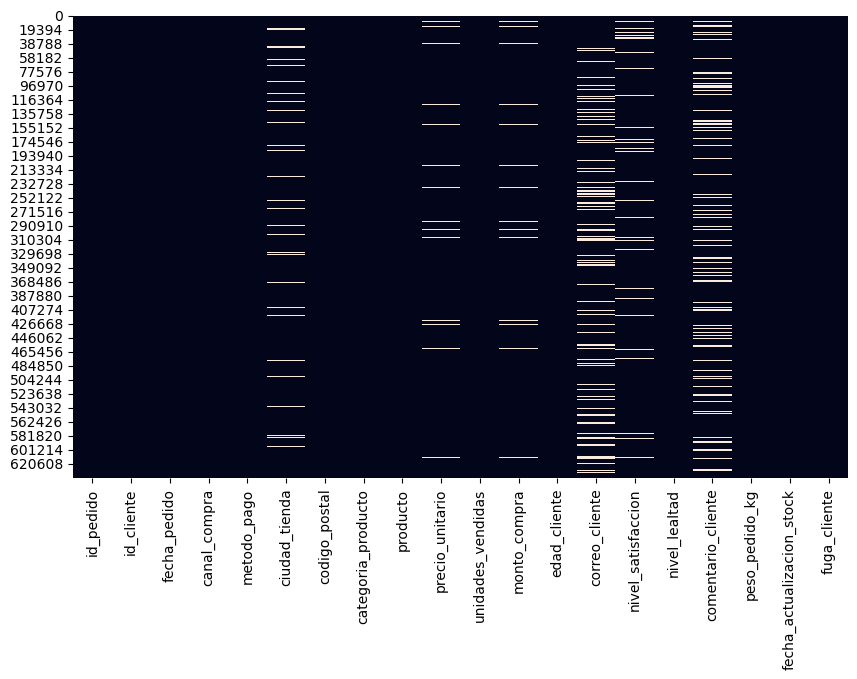

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

# Mecanismo 1, MCAR: cuando el vacío es pura casualidad

## Detección (Comparando Grupos)

In [6]:
# Proporción de categoría de producto en las filas con precio faltante
df[df["precio_unitario"].isnull()]["categoria_producto"].value_counts(normalize=True)

# Proporción de categoría de producto en todo el dataset
df["categoria_producto"].value_counts(normalize=True)

categoria_producto
Belleza         0.088091
Electrónica     0.087908
Deportes        0.087530
Hogar           0.087259
Juguetería      0.086717
Moda            0.086406
moda            0.031803
hogar           0.031800
deportes        0.031798
belleza         0.031677
electronica     0.016302
JUGUETERÍA      0.016144
HOGAR           0.016078
Electrónica     0.016042
DEPORTES        0.016037
Deportes        0.015959
Belleza         0.015930
Moda            0.015909
 Juguetería     0.015891
Hogar           0.015870
 Deportes       0.015855
electrónica     0.015847
 Moda           0.015838
juguetería      0.015833
BELLEZA         0.015803
ELECTRÓNICA     0.015758
 Belleza        0.015706
Juguetería      0.015698
jugueteria      0.015670
MODA            0.015664
 Electrónica    0.015637
 Hogar          0.015539
Name: proportion, dtype: float64

### Conclusión de `precio_unitario`

Se comparan las proporciones de `categoria_producto` entre las filas con `precio_unitario` faltante y el dataset completo. El patrón es compatible con **MCAR** y el porcentaje es 3,38%, menor al 5%; por eso se justifica la eliminación de filas.


### Diagnóstico de `precio_unitario`

Las proporciones de `categoria_producto` entre las filas con `precio_unitario` faltante se comparan con las proporciones del dataset completo. El patrón es compatible con MCAR y el porcentaje de faltantes es 3,38%, menor al 5%.

# Mecanismo 2, MAR: cuando el vacío depende de algo que sí ves

## Detección (tasa de faltantes por grupo)

In [7]:
# Porcentaje de nivel_satisfaccion faltante, por canal de compra
df.groupby("canal_compra")["nivel_satisfaccion"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            19.7
 Marketplace     3.2
 Tienda          2.6
 Web             2.8
APP             19.9
App             20.4
App             19.9
MARKETPLACE      2.6
Marketplace      2.9
Marketplace      3.0
TIENDA           3.2
Tienda           3.0
Tienda           3.2
WEB              2.9
Web              2.8
Web              2.8
app             20.9
marketplace      2.9
tienda           2.9
web              2.8
Name: nivel_satisfaccion, dtype: float64

### Conclusión de `nivel_satisfaccion`

La tasa de faltantes cambia fuertemente según `canal_compra`, especialmente en App frente a Marketplace, Tienda y Web. Esto aporta evidencia de **MAR**, por lo que se imputa usando la moda dentro de cada canal.


## Diagnóstico de `ciudad_tienda`

Se repite el diagnóstico con columnas categóricas observadas relacionadas con la columna que tiene vacíos.


In [8]:
df.groupby("canal_compra")["ciudad_tienda"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            4.6
 Marketplace    4.7
 Tienda         4.8
 Web            4.7
APP             4.9
App             4.7
App             5.0
MARKETPLACE     4.7
Marketplace     4.6
Marketplace     4.6
TIENDA          5.0
Tienda          4.7
Tienda          4.5
WEB             4.9
Web             4.7
Web             5.1
app             4.7
marketplace     4.6
tienda          4.7
web             4.5
Name: ciudad_tienda, dtype: float64

In [9]:
df.groupby("categoria_producto")["ciudad_tienda"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
 Belleza        4.6
 Deportes       4.8
 Electrónica    4.7
 Hogar          4.8
 Juguetería     4.7
 Moda           5.0
BELLEZA         4.9
Belleza         4.6
Belleza         4.7
DEPORTES        4.9
Deportes        4.6
Deportes        4.6
ELECTRÓNICA     4.6
Electrónica     4.6
Electrónica     5.0
HOGAR           4.6
Hogar           4.6
Hogar           4.4
JUGUETERÍA      5.0
Juguetería      4.7
Juguetería      4.8
MODA            4.7
Moda            4.7
Moda            4.6
belleza         4.7
deportes        4.6
electronica     4.9
electrónica     4.4
hogar           4.6
jugueteria      4.8
juguetería      4.6
moda            4.7
Name: ciudad_tienda, dtype: float64

Las tasas observadas son similares y no muestran un grupo que explique claramente el faltante. Por ello, `ciudad_tienda` se documenta como **MNAR sospechado**, pendiente de confirmar con el conocimiento del proceso de negocio. Para el tratamiento se usa `Desconocida` junto con una columna indicadora.


### Conclusión de `ciudad_tienda`

Las tasas de faltantes por `canal_compra` y `categoria_producto` no muestran un grupo que explique claramente el patrón. Por ello, `ciudad_tienda` se documenta como **MNAR sospechado**, pendiente de confirmar con el conocimiento del proceso de negocio. Se usa `Desconocida` junto con una columna indicadora.


## Diagnóstico de `correo_cliente`

Se repite el diagnóstico con distintas columnas categóricas relacionadas.


In [10]:
df.groupby("canal_compra")["correo_cliente"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal_compra
 App            16.6
 Marketplace    16.1
 Tienda         15.9
 Web            16.9
APP             16.3
App             16.6
App             16.1
MARKETPLACE     16.5
Marketplace     16.3
Marketplace     15.4
TIENDA          16.5
Tienda          16.5
Tienda          16.5
WEB             16.3
Web             16.5
Web             17.2
app             16.1
marketplace     16.6
tienda          16.7
web             15.8
Name: correo_cliente, dtype: float64

In [11]:
df.groupby("categoria_producto")["correo_cliente"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
 Belleza        16.4
 Deportes       17.0
 Electrónica    16.7
 Hogar          16.7
 Juguetería     15.8
 Moda           16.3
BELLEZA         17.4
Belleza         16.5
Belleza         16.0
DEPORTES        16.8
Deportes        16.2
Deportes        16.6
ELECTRÓNICA     16.1
Electrónica     16.5
Electrónica     16.8
HOGAR           16.7
Hogar           16.5
Hogar           16.2
JUGUETERÍA      15.7
Juguetería      16.4
Juguetería      16.4
MODA            16.7
Moda            16.3
Moda            16.5
belleza         16.5
deportes        16.5
electronica     16.0
electrónica     16.2
hogar           16.6
jugueteria      16.5
juguetería      15.9
moda            17.0
Name: correo_cliente, dtype: float64

### Conclusión de `correo_cliente`

Las tasas de faltantes por `canal_compra` y `categoria_producto` no muestran un patrón claro que explique la ausencia. Por ello, `correo_cliente` se documenta como **MNAR sospechado**, pendiente de confirmar con el área responsable. No se inventa el correo y se conserva un indicador.


### Diagnóstico de `monto_compra`

`monto_compra` tiene exactamente los mismos registros faltantes que `precio_unitario`, por lo que ambos se resuelven al eliminar las mismas filas.

In [12]:
print("Faltantes en precio_unitario:", df["precio_unitario"].isnull().sum())
print("Faltantes en monto_compra:", df["monto_compra"].isnull().sum())
print("Mismos registros faltantes:", df["precio_unitario"].isnull().equals(df["monto_compra"].isnull()))

Faltantes en precio_unitario: 21640
Faltantes en monto_compra: 21640
Mismos registros faltantes: True


### Conclusión de `monto_compra`

`monto_compra` tiene exactamente los mismos registros faltantes que `precio_unitario`. Al eliminar las filas donde falta `precio_unitario`, se eliminan también los faltantes de `monto_compra`.


### Diagnóstico de `comentario_cliente`

`comentario_cliente` tiene 90.806 faltantes (14,19%). Al ser texto libre, no se inventa el contenido faltante; se conserva la ausencia mediante una columna indicadora y la columna original queda sin imputar.

In [13]:
print("Faltantes en comentario_cliente:", df["comentario_cliente"].isnull().sum())

Faltantes en comentario_cliente: 90806


### Conclusión de `comentario_cliente`

No se observa un patrón claro explicado por las variables categóricas probadas. Se documenta como **MNAR sospechado**; al ser texto libre, no se inventa el contenido y se conserva un indicador.


# Mecanismo 3, MNAR: cuando el vacío depende del propio dato escondido
MNAR son las siglas de Missing Not At Random (faltante no al azar). Significa que la probabilidad de que un dato falte depende del propio valor que falta, ese valor que nunca llegaste a ver. No hay ninguna otra columna del dataset que explique completamente el patrón: la causa está escondida dentro del dato ausente mismo.

### Columnas indicadoras para los faltantes MNAR sospechados

In [14]:
df["correo_cliente_imputado"] = df["correo_cliente"].isnull()
df["comentario_cliente_imputado"] = df["comentario_cliente"].isnull()

In [15]:
print("Faltantes registrados en comentario_cliente:", df["comentario_cliente_imputado"].sum())

Faltantes registrados en comentario_cliente: 90806


In [16]:
print("Faltantes registrados en correo_cliente:", df["correo_cliente_imputado"].sum())

Faltantes registrados en correo_cliente: 105312


`correo_cliente` y `comentario_cliente` se mantienen sin imputar. La columna indicadora conserva la información de que el valor original estaba ausente.

## Aplicando el criterio al dataset de NovaMarket

`precio_unitario` tiene 21 valores faltantes (3,4%) y su patrón es compatible con MCAR. Este es el escenario donde la eliminación por filas es defendible: el porcentaje es bajo y el mecanismo no introduce sesgo. En cambio, ninguna columna del dataset de NovaMarket tiene un porcentaje de faltantes tan alto como para justificar eliminarla por completo, así que la eliminación por columnas no aplica esta semana.

## Tabla de decisiones

| Columna | Mecanismo | % faltante | Estrategia elegida | Justificación |
|---|---|---:|---|---|
| `correo_cliente` | MNAR sospechado | 16,46% | Columna indicadora, sin imputar | Las variables observadas probadas no explican claramente el patrón. No se inventa un correo y se conserva la señal del faltante mediante un indicador. |
| `comentario_cliente` | MNAR sospechado | 14,19% | Columna indicadora, sin imputar | Las variables observadas probadas no explican claramente el patrón y no se debe inventar el contenido de un comentario faltante. |
| `nivel_satisfaccion` | MAR | 7,26% | Imputación por grupo | La tasa de faltantes cambia según `canal_compra`; se imputa con la moda dentro de cada canal. |
| `ciudad_tienda` | MNAR sospechado | 4,68% | Valor constante + indicador | Las variables observadas probadas no explican claramente el patrón. Se usa `Desconocida` y se conserva un indicador. |
| `monto_compra` | MCAR asociado a `precio_unitario` | 3,38% | Eliminación de filas | Tiene los mismos registros faltantes que `precio_unitario`; al eliminar esas filas se eliminan ambos faltantes. |
| `precio_unitario` | MCAR | 3,38% | Eliminación de filas | La comparación de `categoria_producto` es compatible con MCAR y el porcentaje es menor al 5%. |


# Estrategia 1, Eliminación: cuándo borrar es la decisión correcta

## Eliminación por filas (listwise deletion)

In [17]:
print("Shape antes:", df.shape)
df = df.dropna(subset=["precio_unitario"])
print("Shape después:", df.shape)

Shape antes: (640000, 22)
Shape después: (618360, 22)


## Eliminación por columnas
Esta semana no se aplica eliminación por columnas

# Estrategia 2, Imputación simple: rellenar con criterio, no al azar

## Imputación con moda (columnas categóricas)

## Imputación con un valor constante

In [18]:
df["ciudad_tienda_imputado"] = df["ciudad_tienda"].isnull()
df["ciudad_tienda"] = df["ciudad_tienda"].fillna("Desconocida")

In [19]:
print("Faltantes registrados en ciudad_tienda:", df["ciudad_tienda_imputado"].sum())

Faltantes registrados en ciudad_tienda: 28927


## Imputación por grupo (la técnica correcta para un MAR)

In [20]:
df["nivel_satisfaccion_imputado"] = df["nivel_satisfaccion"].isnull()

In [21]:
print("Faltantes registrados en nivel_satisfaccion:", df["nivel_satisfaccion_imputado"].sum())


Faltantes registrados en nivel_satisfaccion: 44892


In [22]:
# Imputa la moda de nivel_satisfaccion, calculada por separado dentro de cada canal
df["nivel_satisfaccion"] = df.groupby("canal_compra")["nivel_satisfaccion"].transform(
    lambda serie: serie.fillna(serie.mode()[0])
)

## Verificación final

In [23]:
df.isnull().sum()

id_pedido                           0
id_cliente                          0
fecha_pedido                        0
canal_compra                        0
metodo_pago                         0
ciudad_tienda                       0
codigo_postal                       0
categoria_producto                  0
producto                            0
precio_unitario                     0
unidades_vendidas                   0
monto_compra                        0
edad_cliente                        0
correo_cliente                 101636
nivel_satisfaccion                  0
nivel_lealtad                       0
comentario_cliente              87733
peso_pedido_kg                      0
fecha_actualizacion_stock           0
fuga_cliente                        0
correo_cliente_imputado             0
comentario_cliente_imputado         0
ciudad_tienda_imputado              0
nivel_satisfaccion_imputado         0
dtype: int64

Después de aplicar las decisiones, las columnas imputadas o eliminadas ya no deben mostrar faltantes. `correo_cliente` y `comentario_cliente` se mantienen sin imputar porque fueron documentadas como MNAR sospechado.

In [24]:
print("Shape final:", df.shape)

Shape final: (618360, 24)


## Guarda el dataset con la imputación inicial

In [25]:
df.to_csv("S04_PD_Sandoval_DatasetImputacionInicial.csv", index=False)

In [26]:
df_exportado = pd.read_csv("S04_PD_Sandoval_DatasetImputacionInicial.csv")
print("Archivo exportado correctamente.")
print(df_exportado.isnull().sum())

Archivo exportado correctamente.
id_pedido                           0
id_cliente                          0
fecha_pedido                        0
canal_compra                        0
metodo_pago                         0
ciudad_tienda                       0
codigo_postal                       0
categoria_producto                  0
producto                            0
precio_unitario                     0
unidades_vendidas                   0
monto_compra                        0
edad_cliente                        0
correo_cliente                 101636
nivel_satisfaccion                  0
nivel_lealtad                       0
comentario_cliente              87733
peso_pedido_kg                      0
fecha_actualizacion_stock           0
fuga_cliente                        0
correo_cliente_imputado             0
comentario_cliente_imputado         0
ciudad_tienda_imputado              0
nivel_satisfaccion_imputado         0
dtype: int64


El archivo generado queda guardado como `S04_PD_Sandoval_DatasetImputacionInicial.csv` en la carpeta de trabajo del notebook.